# Inspect UCI HAR sensor windows

Run this notebook from the repository root. Install `numpy`, `matplotlib`, and (for interactive controls) `ipywidgets` in your notebook kernel. Each window has 128 readings at 50 Hz for nine acceleration and gyroscope channels. Activity labels come from `y_train.txt` and `y_test.txt`.

In [2]:
from pathlib import Path
import sys

# Locate the project from either the repository or notebook working directory.
PROJECT_ROOT = next(
    (folder for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / 'data_loader.py').is_file() and (folder / 'src/har').is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError('Start the notebook kernel inside the HAR-smartphone project.')
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from data_loader import DataLoader

X_train, X_test, y_train, y_test = DataLoader().load_data()
datasets = {'train': (X_train, y_train), 'test': (X_test, y_test)}
activities = {1: 'Walking', 2: 'Upstairs', 3: 'Downstairs', 4: 'Sitting', 5: 'Standing', 6: 'Laying'}
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Shape: (windows, 128 time steps, 9 channels)')

Train: (7352, 128, 9) Test: (2947, 128, 9)
Shape: (windows, 128 time steps, 9 channels)


## Plot a window

Window indices start at 0. Row `i` of the signals and labels refers to the same activity window. Body and total acceleration are in g; gyroscope readings are in rad/s.

In [3]:
def plot_window(split='train', window=0):
    X, y = datasets[split]
    if not 0 <= window < len(X):
        print(f'Choose a window from 0 to {len(X) - 1} for {split}.')
        return

    time = np.arange(X.shape[1]) / 50  # seconds
    groups = [
        ('Body acceleration', 'g', (0, 1, 2)),
        ('Body gyroscope', 'rad/s', (3, 4, 5)),
        ('Total acceleration', 'g', (6, 7, 8)),
    ]
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True, layout='constrained')
    for ax, (name, unit, channels) in zip(axes, groups):
        for channel, axis in zip(channels, 'xyz'):
            ax.plot(time, X[window, :, channel], label=axis)
        ax.set(ylabel=unit, title=name)
        ax.legend(title='Axis', loc='upper right')
        ax.grid(alpha=0.2)
    axes[-1].set_xlabel('Time (s)')
    fig.suptitle(f'{split.title()} window {window} — {activities[int(y[window])]}')
    plt.show()

## Select a window

Use the controls below. If widgets are unavailable, change `split` and `window` in the following cell and rerun it.

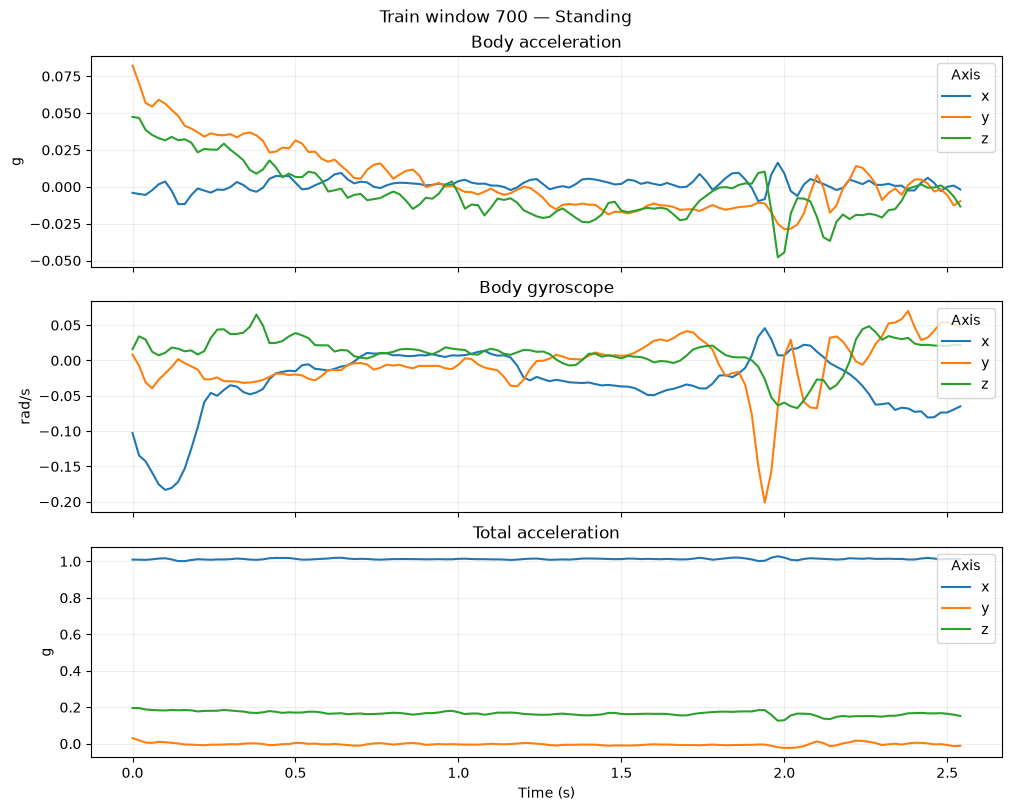

In [4]:
split = 'train'  # 'train' or 'test'
window = 700     # 0–7351 for train, 0–2946 for test
plot_window(split, window)

In [5]:
try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    print('For dropdown and slider controls: pip install ipywidgets')
else:
    split_control = widgets.Dropdown(options=('train', 'test'), description='Split')
    window_control = widgets.IntSlider(min=0, max=len(X_train) - 1, description='Window', continuous_update=False)

    def update_window_range(change):
        window_control.max = len(datasets[change['new']][0]) - 1

    split_control.observe(update_window_range, names='value')
    output = widgets.interactive_output(plot_window, {'split': split_control, 'window': window_control})
    display(widgets.VBox([split_control, window_control, output]))